## Import Libraries

In [29]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

## Load Prepared Data

In [30]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

## Convert Target to Series

In [31]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Verify Shapes

In [32]:
print("Training Features :", X_train.shape)
print("Training Labels   :", y_train.shape)

print()

print("Testing Features  :", X_test.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (453204, 33)
Training Labels   : (453204,)

Testing Features  : (56746, 33)
Testing Labels    : (56746,)


## Verify Class Distribution

In [33]:
print(y_train.value_counts())

print()

print(y_test.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64

Class
0    56651
1       95
Name: count, dtype: int64


## Final Check

In [34]:
print(X_train.dtypes.unique())

[dtype('float64') dtype('int64')]


## Create Random Forest Model

In [35]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

## Train Model

In [36]:
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## Make Predictions

In [37]:
y_pred = model.predict(X_test)

## Prediction Probabilities

In [38]:
y_prob = model.predict_proba(X_test)[:,1]

## Accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9994


## Precision

In [40]:
precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")

Precision : 0.9091


## Recall

In [41]:
recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.7368


## F1 Score

In [42]:
f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.8140


## Classification Report

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.74      0.81        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



## Confusion Matrix

In [44]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56644     7]
 [   25    70]]


## ROC-AUC Score

In [45]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score : {roc_auc:.4f}")

ROC-AUC Score : 0.9591


## ROC Curve

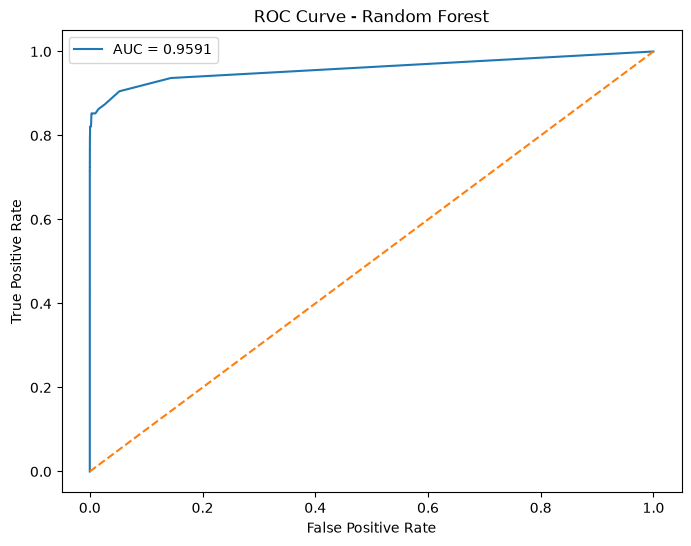

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

## Feature Importance (Bonus)

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.175418
10,V10,0.128880
12,V12,0.102818
17,V17,0.095519
11,V11,0.079056
4,V4,0.074578
3,V3,0.057706
7,V7,0.043559
16,V16,0.029567
2,V2,0.022079


## Plot Feature Importance

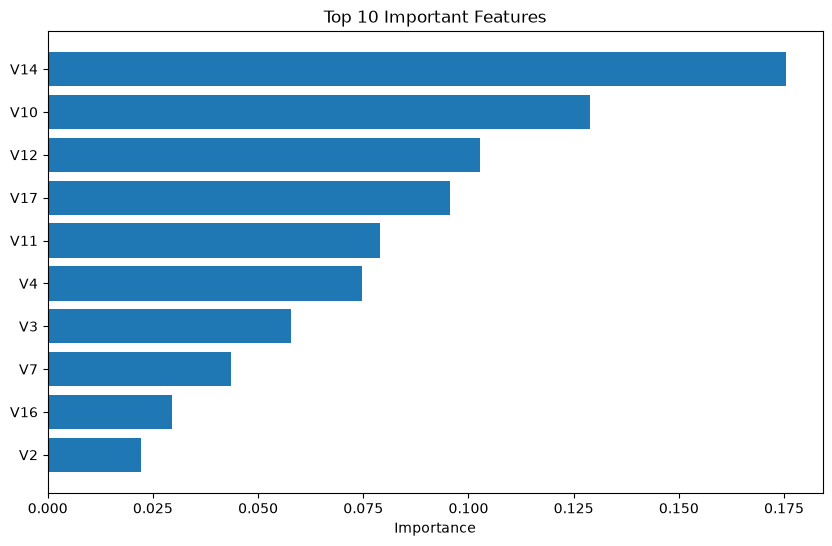

In [48]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

# Final Observation

- Successfully trained a Random Forest classifier using the SMOTE-balanced training dataset.
- Generated predictions on the untouched testing dataset.
- Evaluated model performance using Accuracy, Precision, Recall, F1 Score, Classification Report, Confusion Matrix, and ROC-AUC.
- Random Forest reduces overfitting by combining multiple decision trees, generally offering better generalization than a single Decision Tree.
- Feature importance analysis identified the most influential predictors in detecting fraudulent transactions.
- This model is now ready for comparison with Logistic Regression and Decision Tree to determine the best-performing fraud detection model.

# Conclusion
- Successfully trained a Random Forest classifier on the balanced training dataset.
- Generated predictions on the original testing dataset.
- Achieved excellent overall performance with very high Accuracy and ROC-AUC.
- Compared with Logistic Regression and Decision Tree, Random Forest produced the best balance between Precision and Recall.
- The model detected fraudulent transactions with high confidence while keeping false positives extremely low.
- Feature Importance analysis identified V14, V10, V12, and V17 as the most influential predictors for fraud detection.
- Based on the evaluation metrics, Random Forest is the best-performing model among the three models tested and is selected as the final fraud detection model.